In [1]:
# These modules are required for working with the data.
from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.log import init_logging
from astropy import units as u
from dysh.spectra.spectrum import Spectrum

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(test="getps")

16:10:18.063 I Resolving test=getps -> AGBT05B_047_01/AGBT05B_047_01.raw.acs/


In [4]:
sdfits = GBTFITSLoad(filename)
sdfits.summary()

16:10:18.236 I Index loaded from .index file (44/93 columns). Missing columns (TCAL, WCS, calibration metadata, etc.) will be automatically loaded from FITS file when first accessed.


SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
51,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,198.3431,18.6427
52,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,198.9306,18.7872
53,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,199.3305,18.3561
54,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,199.9157,18.4927
55,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,200.3042,18.0575
56,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,200.8906,18.1860
57,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,202.3275,17.3853
58,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,202.9192,17.4949


In [5]:
ta = sdfits.getps(scan=51, ifnum=0, plnum=0, fdnum=0).timeaverage()

In [6]:
sdfits["CTYPE1"][0]

nan

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


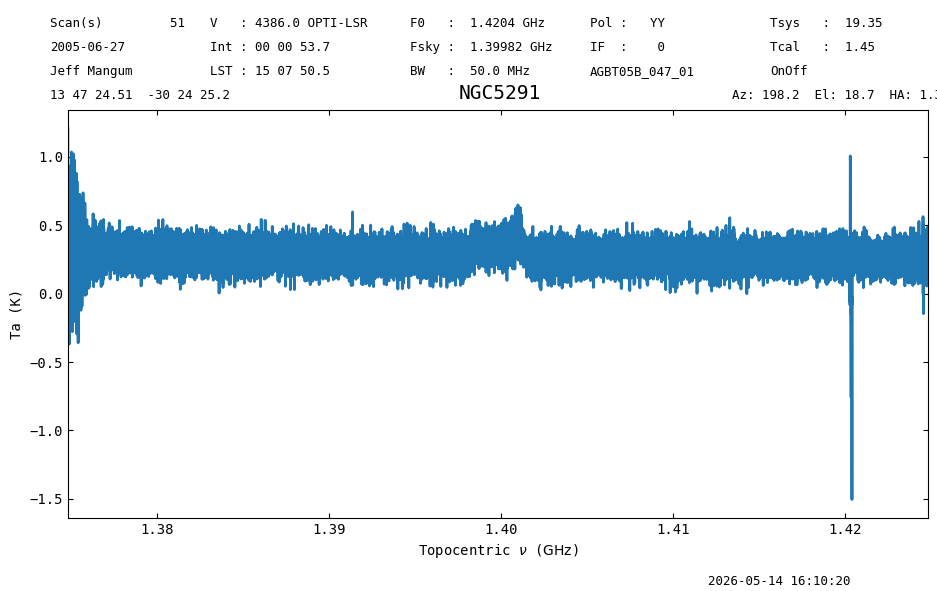

In [7]:
ta.plot();

In [8]:
print(ta)
print("\n")
ta

Spectrum (length=32768)
Flux=[0.2448421  0.31819268 0.19866335 ... 0.57650381 0.2179878
      1.20767879] K,  mean=0.28071 K
Spectral Axis=[1.42481684e+09 1.42481531e+09 1.42481379e+09 ...
               1.37482142e+09 1.37481989e+09 1.37481836e+09] Hz,  mean=1399817601.06055 Hz




<Spectrum(flux=[0.24484210085049396 ... 1.2076787931163384] K (shape=(32768,), mean=0.28071 K); spectral_axis=<SpectralAxis 
   (observer: <ITRS Coordinate (obstime=2005-06-27T02:05:58.000, location=(0.0, 0.0, 0.0) km): (x, y, z) in m
                  (882593.9465029, -4924896.36541728, 3943748.74743984)
               (v_x, v_y, v_z) in km / s
                  (0., 0., 0.)>
    target: <SkyCoord (FK5: equinox=J2000.000): (ra, dec, distance) in (deg, deg, kpc)
                (206.85210758, -30.40701531, 1000000.)
             (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
                (0., 0., 4386.)>
    observer to target (computed from above):
      radial_velocity=4410.070039086893 km / s
      redshift=0.014820217767934851
    doppler_rest=1420405000.0 Hz
    doppler_convention=optical)
  [1.42481684e+09 1.42481531e+09 1.42481379e+09 ... 1.37482142e+09
 1.37481989e+09 1.37481836e+09] Hz> (length=32768))>

In [9]:
dict(sorted(ta.meta.items()))

{'AP_EFF': np.float64(0.6094633241501576),
 'AZIMUTH': 198.1588901992111,
 'BACKEND': 'Spectrometer',
 'BANDWID': 50000000.0,
 'BANDWIDTH': 50000000.0,
 'BINTABLE': 0,
 'BUNIT': 'K',
 'CAL': 'F',
 'CALPOSITION': 'Unknown',
 'CALTYPE': 'LOW',
 'CDELT1': -1525.87890625,
 'CRPIX1': 16385.0,
 'CRVAL1': 1399816838.1210938,
 'CRVAL2': np.float64(206.85210757719534),
 'CRVAL3': np.float64(-30.407015310885345),
 'CRVAL4': -6.0,
 'CTYPE1': 'FREQ-OBS',
 'CTYPE2': 'RA',
 'CTYPE3': 'DEC',
 'CTYPE4': 'STOKES',
 'CUNIT1': 'Hz',
 'CUNIT2': 'deg',
 'CUNIT3': 'deg',
 'DATE': '2005-06-27',
 'DATE-OBS': '2005-06-27T02:05:58.00',
 'DOPFREQ': 1420405000.0,
 'DURATION': np.float64(55.5225),
 'E2ESC': 0,
 'ELEVATIO': 18.69449298449073,
 'EQUINOX': 2000.0,
 'EXPOSURE': np.float64(53.7157844463702),
 'EXTEND': True,
 'EXTNAME': 'SINGLE DISH',
 'FDNUM': 0,
 'FEED': 1,
 'FEEDEOFF': 0.0,
 'FEEDXOFF': 0.0,
 'FILE': 'AGBT05B_047_01.raw.acs.fits',
 'FITSINDEX': 0,
 'FITSVER': '1.9',
 'FREQINT': -1525.878906,
 'FREQR

Taking a zoomed spectrum


Spectrum (length=3)
Flux=[0.33822484 0.59789101 0.26609857] K,  mean=0.40074 K
Spectral Axis=[1.39136957e+09 1.39136805e+09 1.39136652e+09] Hz,  mean=1391368046.61719 Hz


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


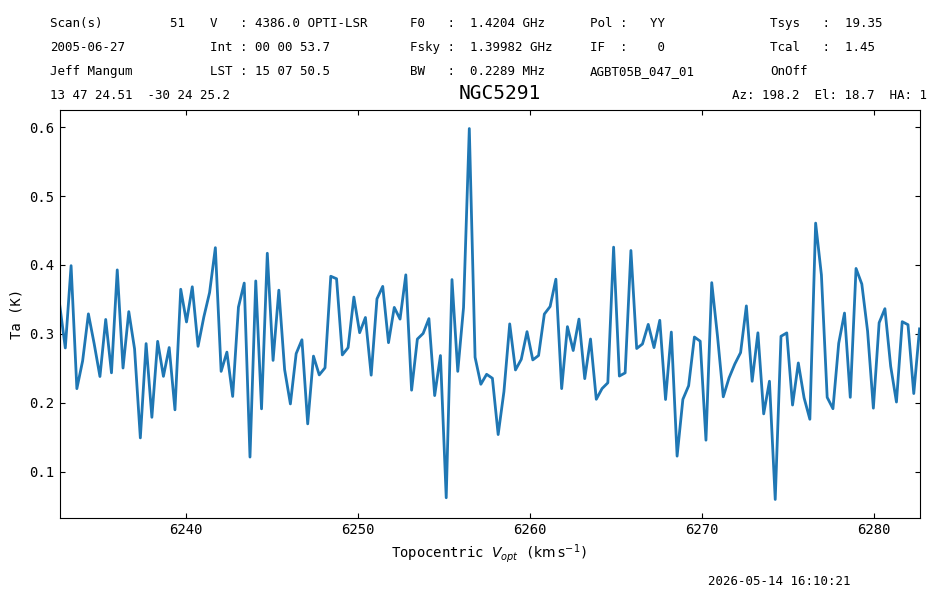

Peak at 6256.475163870069 km / s in the itrs reference frame


In [10]:
# pick a zoomed spectrum  (this cell is safe to re-execute)
if ta.nchan > 1000:
    print(f"Taking a zoomed spectrum")
    print(ta[21920:21923])   # print values around the spike, peak is at channel 21921
    ta = ta[21850:22000]     # these are the 150 channels we will zoom into
else:
    print(f"Already had the zoomed spectrum of {ta.nchan} channels")
    print(ta[70:73])         # peak is at channel 71

ta.plot(xaxis_unit='km/s')
print(f"Peak at {ta.velocity_axis_to('km/s')[71]} in the {ta.velocity_frame} reference frame")

In [11]:
# helper function to show the first few lines of a file
def head(filename, nlines=3):
    """ emulate the unix `head` program
    """
    with open(filename, 'r') as file:
        for i, line in enumerate(file, 1):
            print(line.strip())
            if i == nlines:
                break

spike_table = "output/ngc5291_spike.tab"

In [12]:
ta.write(spike_table,format="ascii.commented_header", overwrite=True)  
head(spike_table)

# spectral_axis flux uncertainty weight mask baseline
1391476384.0195374 0.34372934266958427 0.0 218.81991773344748 0 0.0
1391474858.1406312 0.27963123045821414 0.0 218.81991773344748 0 0.0


In [13]:
ta1 = ta.with_spectral_axis_unit("km/s")
ta1.write(spike_table,format="ascii.commented_header", overwrite=True)  
head(spike_table)

# spectral_axis flux uncertainty weight mask baseline
6232.6468425347 0.34372934266958427 0.0 218.75420976172921 0 0.0
6232.982426932423 0.27963123045821414 0.0 218.75420976172921 0 0.0


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


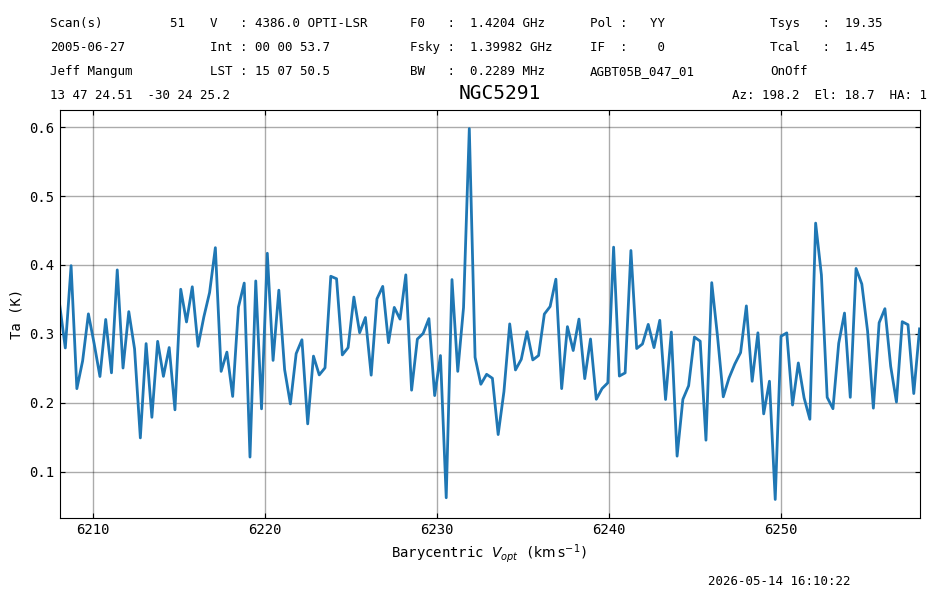

In [14]:
ta.plot(vel_frame='icrs', xaxis_unit='km/s', grid=True);

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


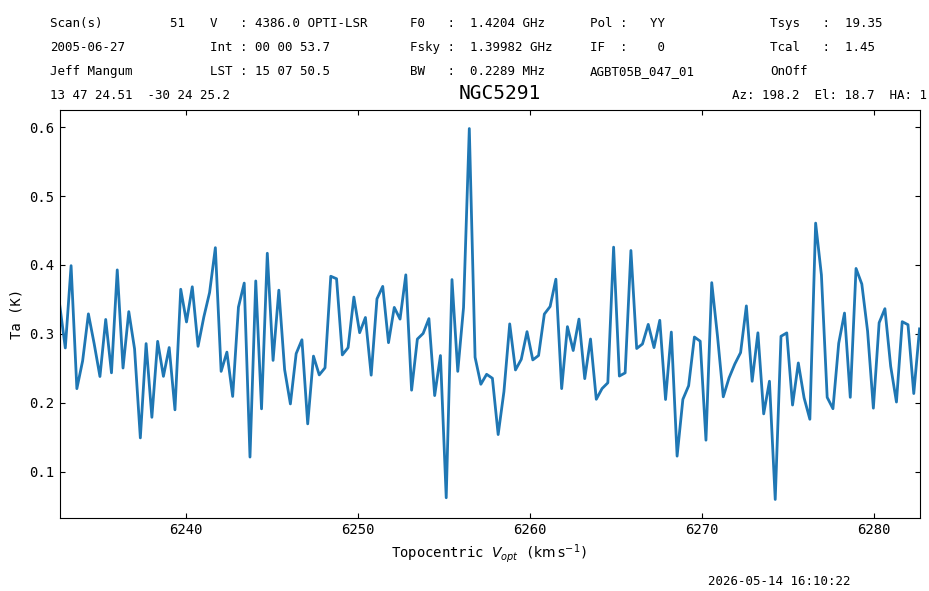

In [15]:
ta.plot(vel_frame='topo', xaxis_unit='km/s');

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


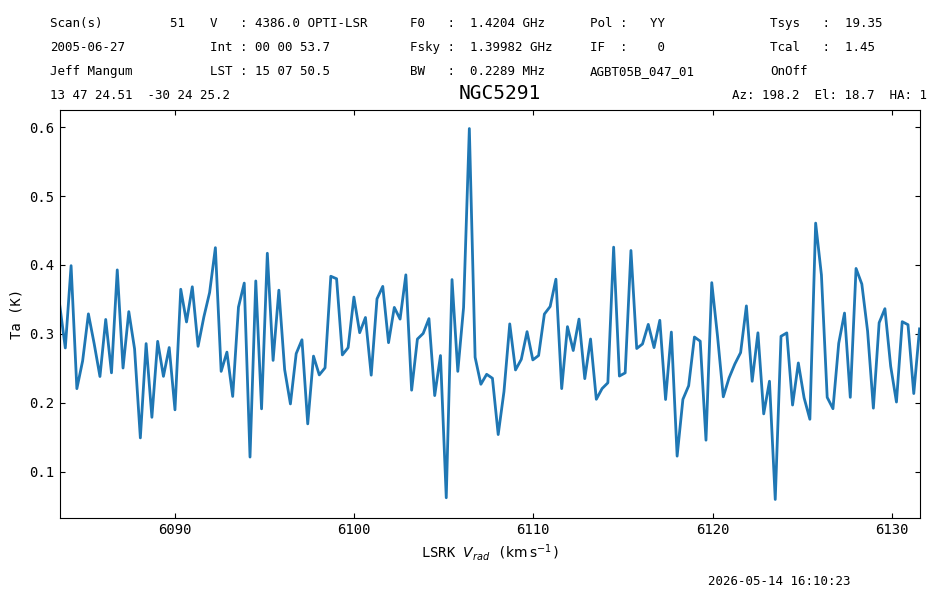

In [16]:
ta.plot(vel_frame='lsrk', doppler_convention='radio', xaxis_unit='km/s');

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


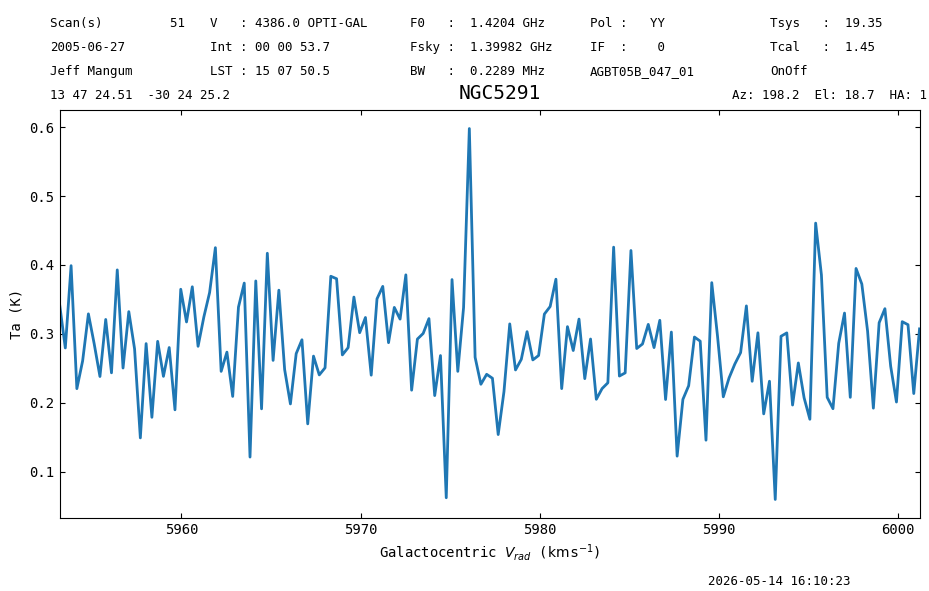

In [17]:
newspec = ta.with_frame('galactocentric')
newspec.plot(xaxis_unit="km/s",doppler_convention='radio')

In [18]:
print(f"The new spectral axis frame is {newspec.velocity_frame}")
print('radio:  ',newspec.velocity_axis_to("km/s", doppler_convention="radio")[71])     # 5976.1
print('default:',newspec.velocity_axis_to("km/s")[71],  newspec.velocity_convention)   # 6097.6

The new spectral axis frame is galactocentric
radio:   5976.071520424437 km / s
default: 6097.621687333563 km / s optical


In [19]:
ta.spectral_axis - newspec.spectral_axis


<Quantity [-722615.33079433, -722614.53838181, -722613.74596906,
           -722612.9535563 , -722612.16114378, -722611.36873102,
           -722610.5763185 , -722609.78390574, -722608.99149323,
           -722608.19908047, -722607.40666795, -722606.61425519,
           -722605.82184243, -722605.02942991, -722604.23701715,
           -722603.44460464, -722602.65219188, -722601.85977936,
           -722601.0673666 , -722600.27495408, -722599.48254132,
           -722598.69012856, -722597.89771605, -722597.10530329,
           -722596.31289077, -722595.52047801, -722594.72806549,
           -722593.93565273, -722593.14324021, -722592.35082746,
           -722591.55841494, -722590.76600218, -722589.97358942,
           -722589.1811769 , -722588.38876414, -722587.59635162,
           -722586.80393887, -722586.01152635, -722585.21911359,
           -722584.42670107, -722583.63428831, -722582.84187555,
           -722582.04946303, -722581.25705028, -722580.46463776,
           -722579.672225

In [20]:
print(ta.velocity_axis_to("km/s")[71]) # 6256.475
sa = ta.spectral_axis
ta.set_frame('gcrs')
print(f"Changed spectral axis frame to  {ta.velocity_frame}")
print(ta.velocity_axis_to("km/s")[71]) # 6256.365

6256.475163870069 km / s
Changed spectral axis frame to  gcrs
6256.365280719197 km / s


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


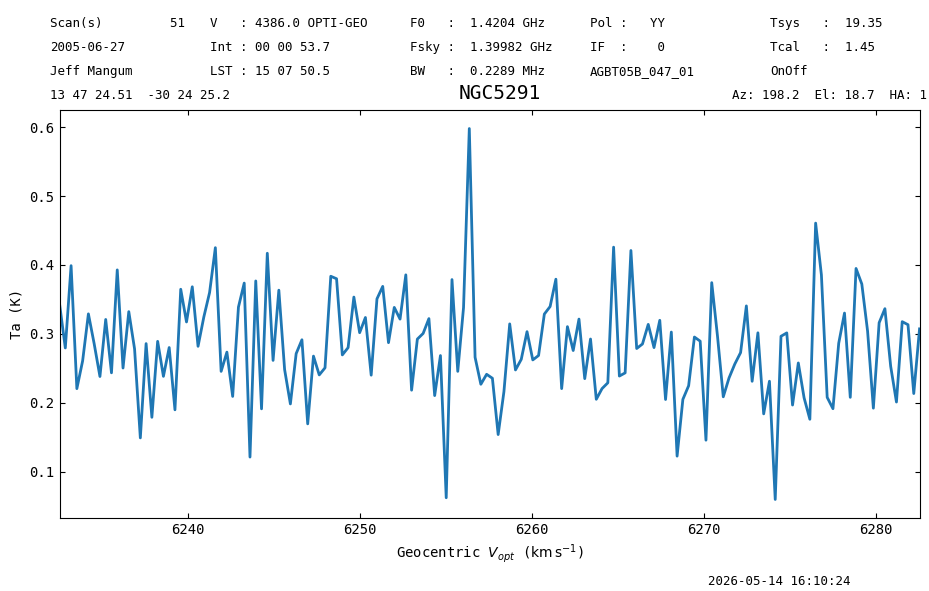

In [21]:
ta.plot(xaxis_unit="km/s");

In [22]:
ta.spectral_axis - sa

<Quantity [499.59286833, 499.59232044, 499.59177256, 499.59122467,
           499.59067702, 499.59012914, 499.58958125, 499.58903337,
           499.58848548, 499.58793759, 499.58738995, 499.58684206,
           499.58629417, 499.58574629, 499.5851984 , 499.58465052,
           499.58410263, 499.58355498, 499.5830071 , 499.58245921,
           499.58191133, 499.58136344, 499.58081555, 499.58026791,
           499.57972002, 499.57917213, 499.57862425, 499.57807636,
           499.57752848, 499.57698083, 499.57643294, 499.57588506,
           499.57533717, 499.57478929, 499.5742414 , 499.57369351,
           499.57314587, 499.57259798, 499.57205009, 499.57150221,
           499.57095432, 499.57040644, 499.56985879, 499.5693109 ,
           499.56876302, 499.56821513, 499.56766725, 499.56711936,
           499.56657147, 499.56602383, 499.56547594, 499.56492805,
           499.56438017, 499.56383228, 499.5632844 , 499.56273675,
           499.56218886, 499.56164098, 499.56109309, 499.56054

In [23]:
ta.set_convention('radio')

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


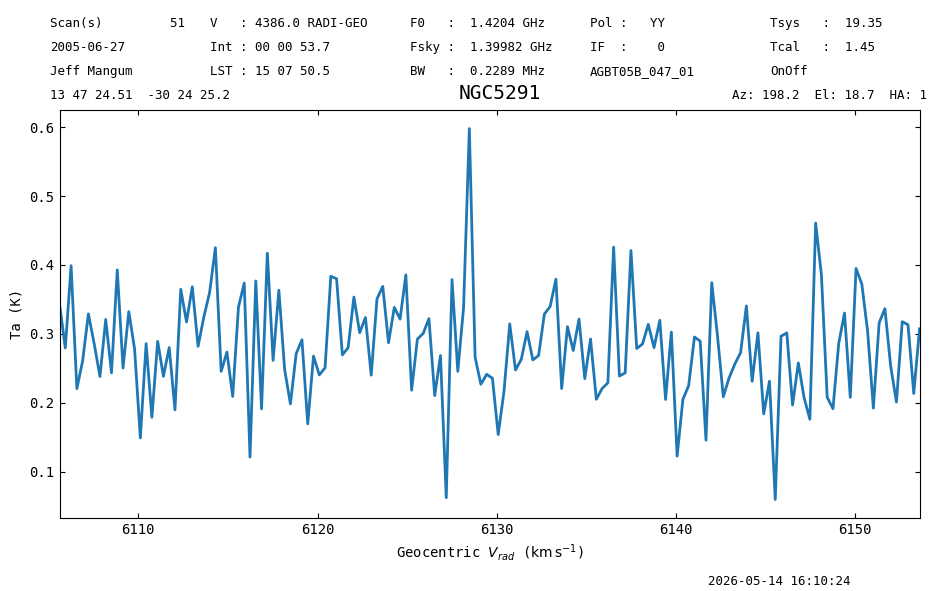

6128.470305969091 km / s


In [24]:
ta.plot(xaxis_unit="km/s")
print(ta.velocity_axis_to("km/s")[71])

In [25]:
ta.target

<SkyCoord (FK5: equinox=J2000.000): (ra, dec, distance) in (deg, deg, kpc)
    (206.85210758, -30.40701531, 1000000.)
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    (0., 0., 4386.)>

In [26]:
ta.observer

<GCRS Coordinate (obstime=2005-06-27T02:05:58.000, obsgeoloc=(0., 0., 0.) m, obsgeovel=(0., 0., 0.) m / s): (x, y, z) in m
    (-3418483.37116048, -3651331.51587568, 3945691.32972075)
 (v_x, v_y, v_z) in km / s
    (-4.3110922e-08, 9.51169059e-08, 6.55464828e-08)>

In [27]:
ta.velocity_axis_to(unit="pc/Myr", toframe='heliocentric', doppler_convention='radio')

<SpectralAxis 
   (observer: <HCRS Coordinate (obstime=2005-06-27T02:05:58.000): (x, y, z) in m
                  (1.44835706e+10, -1.38895619e+11, -6.02107693e+10)
               (v_x, v_y, v_z) in km / s
                  (0., 0., 0.)>
    target: <FK5 Coordinate (equinox=J2000.000): (ra, dec, distance) in (deg, deg, kpc)
                (206.85210758, -30.40701531, 1000000.)
             (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
                (0., 0., 4386.)>
    observer to target (computed from above):
      radial_velocity=4386.005213365332 km / s
      redshift=0.014738742242065506
    doppler_rest=1420405000.0 Hz
    doppler_convention=radio)
  [6220.27269497, 6220.60208987, 6220.93148476, 6221.26087966,
   6221.59027455, 6221.91966945, 6222.24906434, 6222.57845924,
   6222.90785413, 6223.23724902, 6223.56664392, 6223.89603881,
   6224.22543371, 6224.5548286 , 6224.8842235 , 6225.21361839,
   6225.54301328, 6225.87240818, 6226.20180307, 6226.5311

In [28]:
print(ta.velocity_axis_to("km/s")[71])

6128.470305969091 km / s


In [29]:
print(f"before shift {ta.spectral_axis[0]}...")
ta.shift_spectrum_to(radial_velocity=0*u.km/u.s)
print(f"after shift {ta.spectral_axis[0]}...")

before shift 1391476883.6124058 Hz...


after shift 1412098366.9399488 Hz...


Set OBSGEO-B to    -1.108897 from OBSGEO-[XYZ].
Set OBSGEO-H to -6378059.370 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [30]:
ta.wavelength.to('cm')

<SpectralAxis 
   (observer: <GCRS Coordinate (obstime=2005-06-27T02:05:58.000, obsgeoloc=(0., 0., 0.) m, obsgeovel=(0., 0., 0.) m / s): (ra, dec, distance) in (deg, deg, m)
                  (226.88638534, 38.2681561, 6370771.57549705)
               (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
                  (-33132.93080836, 103576.96454981, -4.73214035e-08)>
    target: <FK5 Coordinate (equinox=J2000.000): (ra, dec, distance) in (deg, deg, kpc)
                (206.85210758, -30.40701531, 1000000.)
             (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
                (3.83414117e-18, -6.25026835e-19, -23.96240223)>
    observer to target (computed from above):
      radial_velocity=-7.723204298315522e-09 km / s
      redshift=-2.5757174171303632e-14
    doppler_rest=1420405000.0 Hz
    doppler_convention=radio)
  [21.23028147, 21.23030476, 21.23032804, 21.23035132, 21.2303746 ,
   21.23039788, 21.23042116, 21.23044444, 21

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


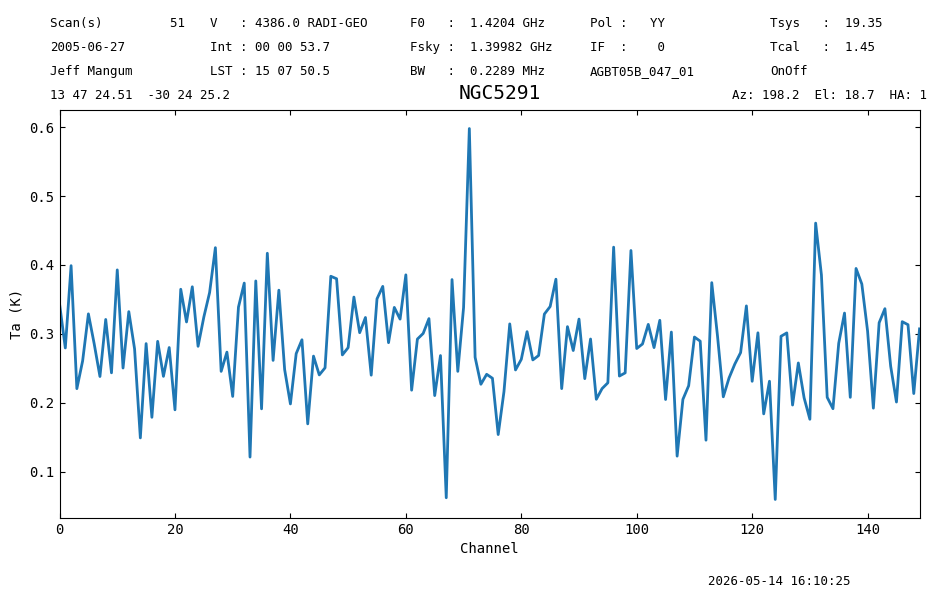

In [31]:
ta.plot(xaxis_unit='chan');

In [32]:
ta.check_stats(0.07586939 * u.K)

16:10:25.888 I rms is OK 
